In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
import matplotlib.pyplot as plt

from pathlib import Path

from dfmodel import DigitalFamilyBinary
from networkx.classes import non_neighbors

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [2]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [3]:
training_data = pd.read_csv(
    "cluster_results.csv"
)

In [4]:
palette = sns.color_palette(palette='pastel', n_colors=4)
palette

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019)]

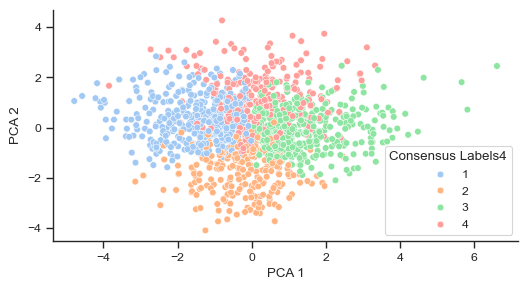

In [5]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue="Consensus Labels4",
    ax=ax,
    palette=palette,
)
sns.despine()

fig.set_size_inches(
    (6, 3)
)

fig.savefig(
    "clusters.pdf", dpi=300, bbox_inches="tight"
)

sao2_ambulance


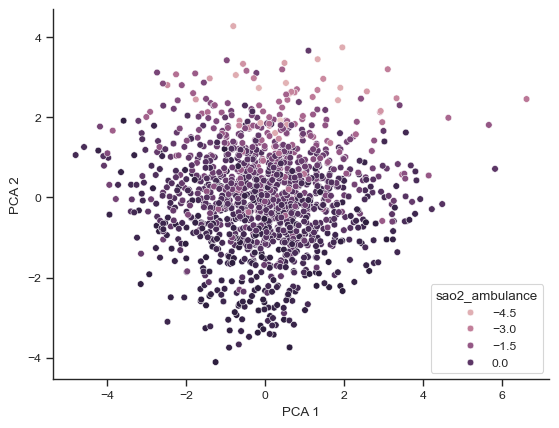

resp_frequency_ambulance


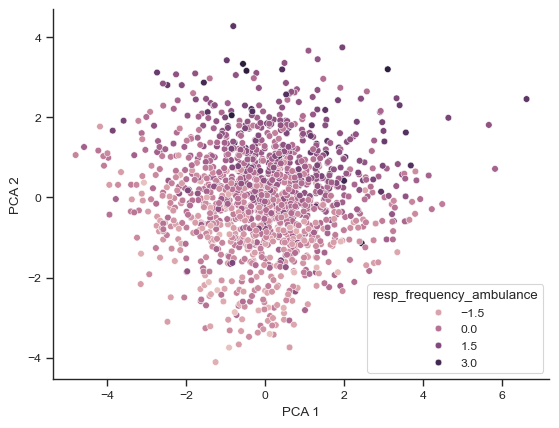

heart_rate_ambulance


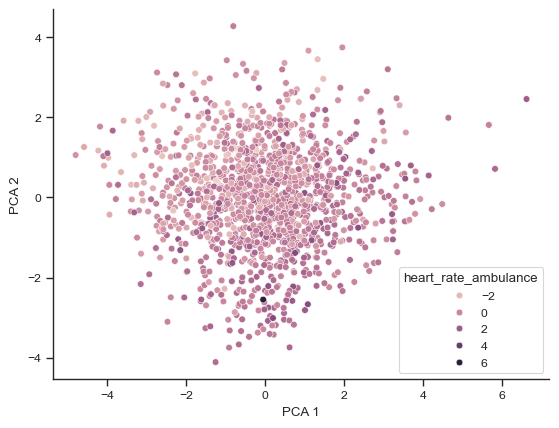

syst_bp_ambulance


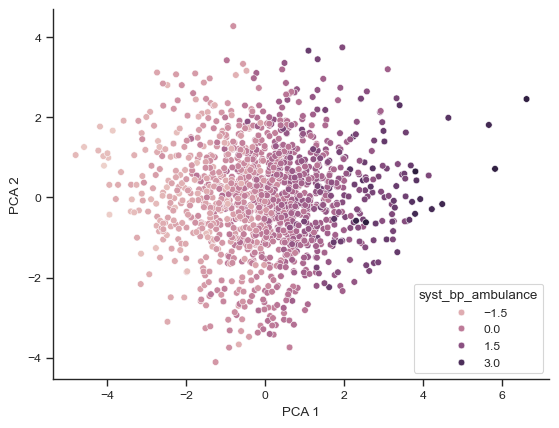

map_ambulance


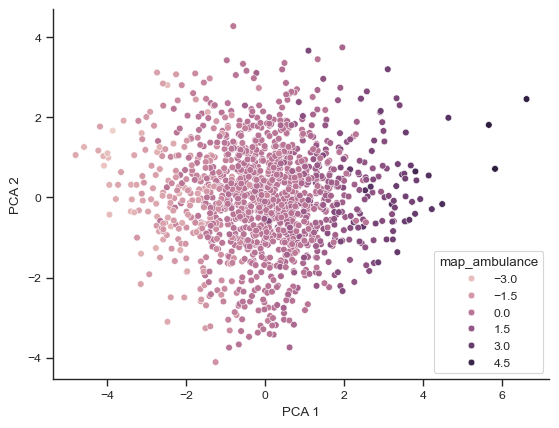

mental_status_ambulance


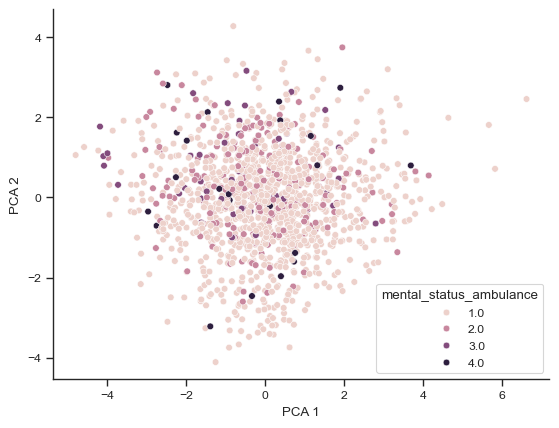

temperature_ambulance


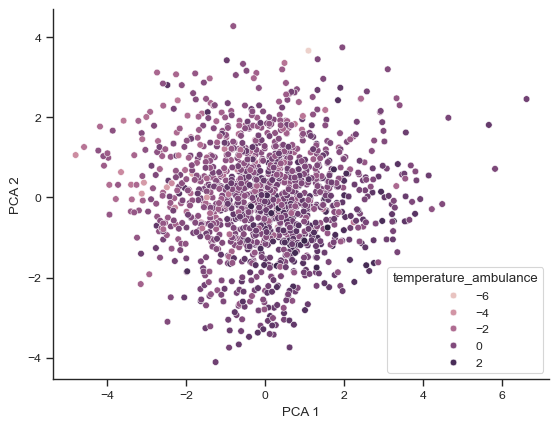

crea_emergency_department


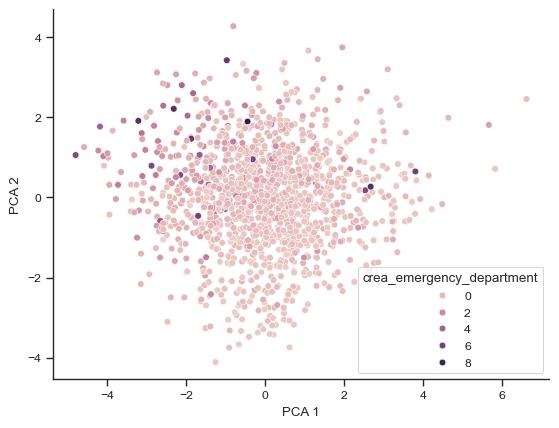

bili_emergency_department


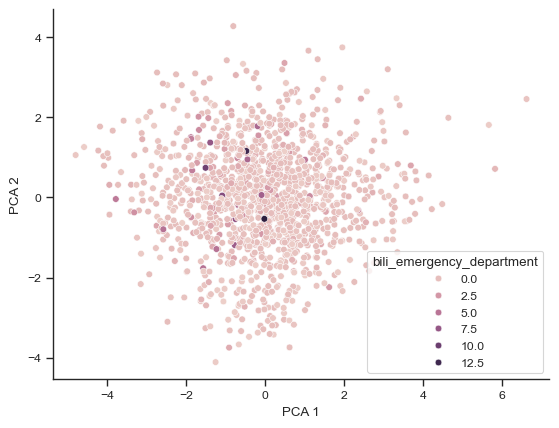

crp_day1


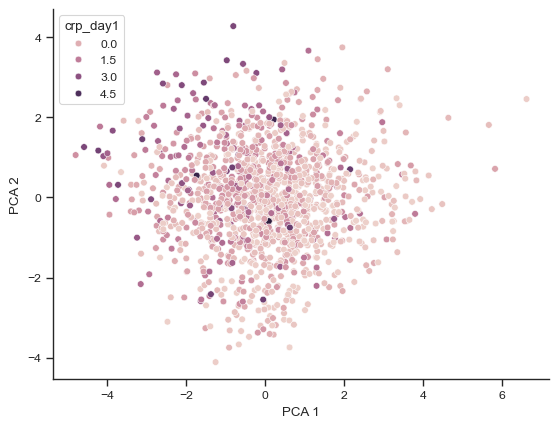

trc_emergency_department


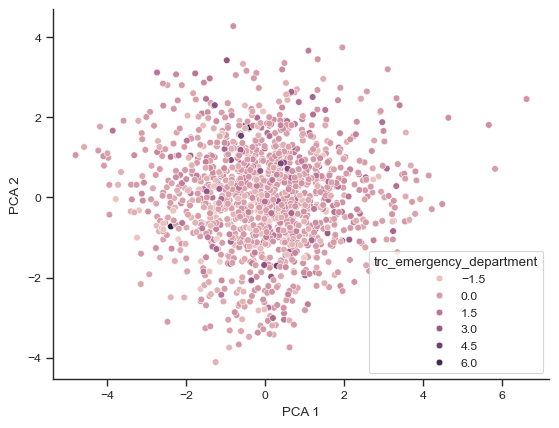

sex


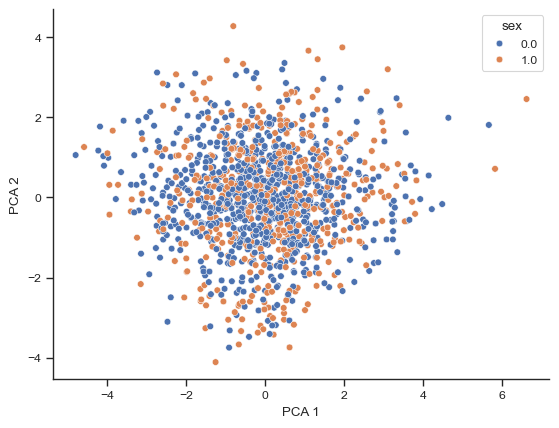

age


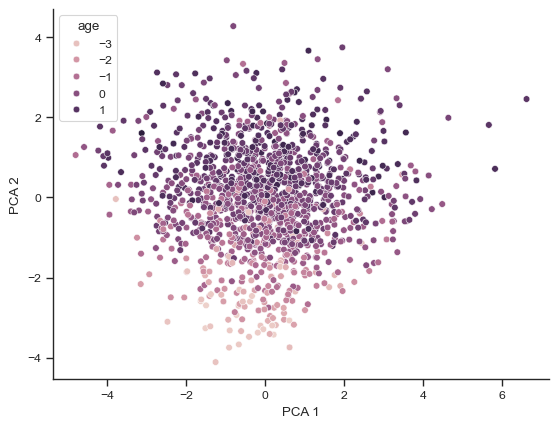

In [6]:
for col in clinical_columns:

    print(col)
    sns.scatterplot(
        data=training_data,
        x="PCA 1",
        y="PCA 2",
        hue=col
    )
    plt.show()

In [7]:

col = f"Consensus Labels4"

cluster_names = training_data[col].unique()

In [8]:
long = training_data.melt(
    id_vars=[col],    value_vars=clinical_columns,

)
long[col] = long[col].astype("category")

In [9]:
long.to_csv(
    "clinical_data_long.csv",
    index=False,
)

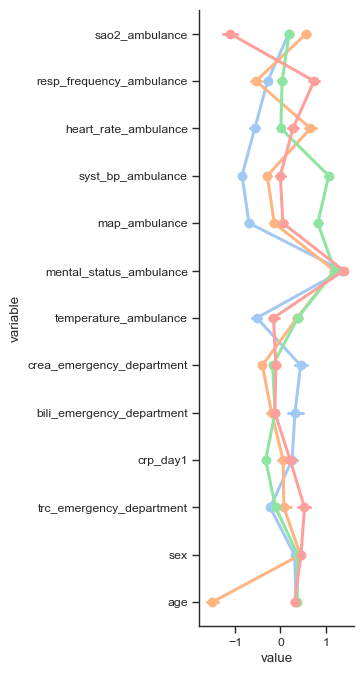

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
)
sns.pointplot(
    data=long,
    y="variable",
    x="value",
    hue="Consensus Labels4",
    ax=axs,
    palette=palette,
    legend=False,
    errorbar=("ci", 95)
)

#axs.set_xticklabels(axs.get_xticklabels(), rotation=90)

sns.despine()

fig.set_size_inches((2, 8))

fig.savefig(
    "cluster_variables.pdf", dpi=300, bbox_inches="tight"
)

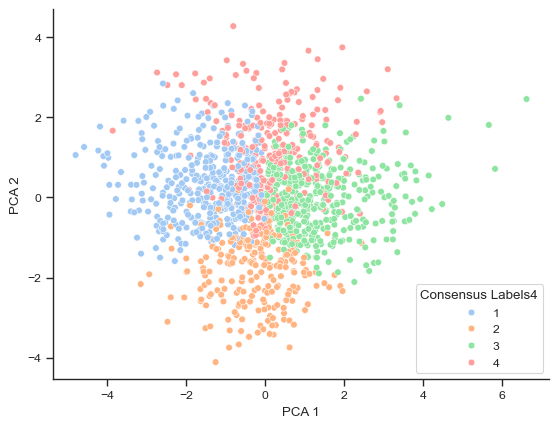

In [11]:

sns.scatterplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue=col,
    palette=palette,
)
plt.show()

In [12]:
cluster_centroids = dict()

for i, cluster_name in enumerate(cluster_names):

    subset_training_data = training_data[training_data[col] == cluster_name].copy()

    cluster_centroids[cluster_name] = subset_training_data[clinical_columns].mean()

In [13]:
centroids = pd.DataFrame.from_dict(cluster_centroids, orient="index")

In [14]:
centroids

,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,crp_day1,trc_emergency_department,sex,age
2,0.566585,-0.537932,0.660140,-0.290908,-0.137756,1.186235,0.363618,-0.399501,-0.197473,0.057569,0.074294,0.437247,-1.505720
4,-1.114184,0.738342,0.273790,-0.005085,0.052821,1.391459,-0.154675,-0.101889,-0.123640,0.212817,0.528473,0.451957,0.308886
1,0.182930,-0.283133,-0.567633,-0.847428,-0.692423,1.363409,-0.521226,0.441949,0.318692,0.254732,-0.229474,0.310777,0.345335
3,0.190923,0.035500,0.007711,1.061958,0.820969,1.196305,0.381589,-0.173187,-0.119218,-0.328423,-0.107316,0.378753,0.367257


In [15]:
from joblib import load

with open("pca.pickle", "rb") as f:
    pca = load(f)

In [16]:
components = pca.transform(centroids)

In [17]:
centroids['PCA 1'] = components[:, 0]
centroids['PCA 2'] = components[:, 1]

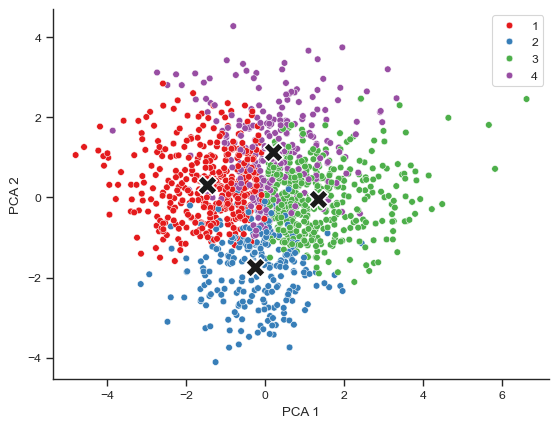

In [18]:

sns.scatterplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue=col,
    palette="Set1",
)

sns.scatterplot(
    x=centroids["PCA 1"],
    y=centroids["PCA 2"],
    c="k",
    marker="X",
    s=200
)

plt.show()

In [19]:
from sklearn.metrics import silhouette_samples

training_data['Silhoutte Samples'] = silhouette_samples(
    training_data[clinical_columns],
    labels=training_data["Consensus Labels4"],
)




In [20]:
training_data = training_data.sort_values(
    by=["Consensus Labels4", "Silhoutte Samples"],
    ascending=[True, True]
)

In [21]:
training_data['X_axis'] = np.arange(training_data.shape[0])

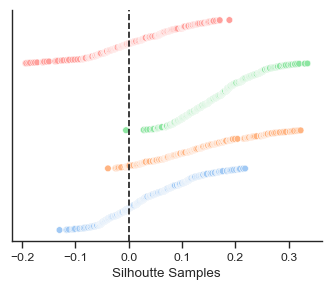

In [22]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=training_data,
    y="X_axis",
    x="Silhoutte Samples",
    hue="Consensus Labels4",
    ax=ax,
    palette=palette,
    legend=False
)

sns.despine()

ax.axvline(0.0, color="k", linestyle="--")

fig.set_size_inches(
    (4, 3)
)

ax.set_ylabel("")
ax.set_yticklabels([])
ax.set_yticks([])

fig.savefig(
    "silhouette_samples.pdf", dpi=300, bbox_inches="tight"
)

<Axes: xlabel='Silhoutte Samples', ylabel='Count'>

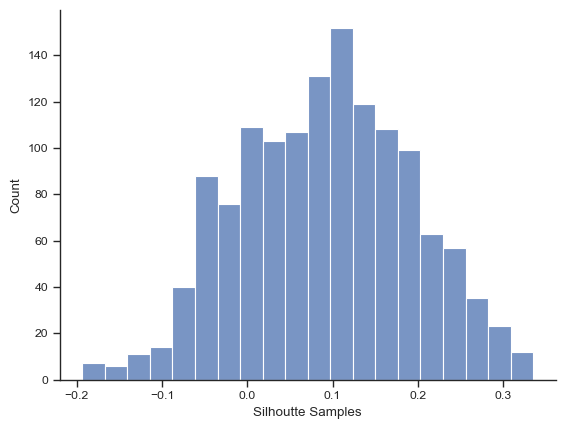

In [23]:
sns.histplot(
    data=training_data,
    x="Silhoutte Samples",
)

In [24]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)

In [25]:
neighbors.fit(training_data[clinical_columns])

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [26]:
dist, ind = neighbors.kneighbors(training_data[clinical_columns])

In [27]:
training_data['30_day_mortality'] = np.where(
    training_data['survival_days'] <= 30, 1, 0
)

In [28]:
mortality_rates = []

for i in range(ind.shape[0]):

    sample_neigh_ind = ind[i, :]

    sample_neighbors = training_data.iloc[sample_neigh_ind, :]
    mortality_rates.append(
        sample_neighbors['30_day_mortality'].sum() / sample_neighbors.shape[0]
    )

training_data['30 Day Mortality'] = mortality_rates

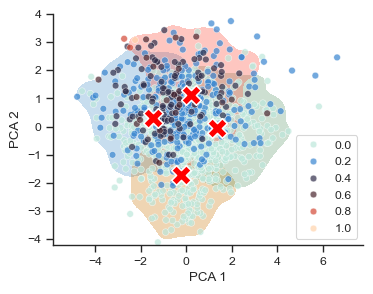

In [29]:
fig, ax = plt.subplots()


sns.kdeplot(
    data=training_data,
    x="PCA 1",
    y="PCA 2",
    hue="Consensus Labels4",
    alpha=0.3,
    palette=palette,
    ax=ax,
    levels=2,
    fill=True,

)


sns.scatterplot(
    data=training_data.sort_values(by="30 Day Mortality", ascending=True),
    x="PCA 1",
    y="PCA 2",
    hue="30 Day Mortality",
    ax=ax,
    palette="icefire",
    alpha=0.7,
    #s=100
)


sns.scatterplot(
    x=centroids["PCA 1"],
    y=centroids["PCA 2"],
    c="red",
    marker="X",
    s=200
)

ax.set_ylim([-4.2, 4])
#fig.set_size_inches((10, 7))

sns.despine()

fig.set_size_inches(4, 3)

# fig.savefig(
#     "cluster_gradients.pdf", dpi=300, bbox_inches="tight"
# )


In [30]:
palette

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019)]

0
1
2
3


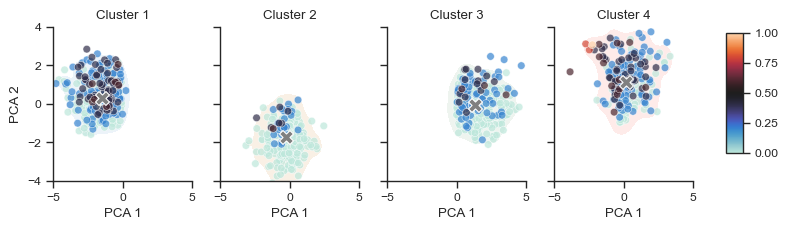

In [31]:



from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    sharey=True,
    sharex=True,
)

ax = ax.flatten()

norm = Normalize(vmin=training_data['30 Day Mortality'].min(), vmax=training_data['30 Day Mortality'].max())
cmap = sns.color_palette("icefire", as_cmap=True)

for i in [1, 2, 3, 4]:

    subset = training_data[training_data['Consensus Labels4'] == i]

    subset = subset.sort_values(by="30 Day Mortality", ascending=True)

    colors = cmap(norm(subset['30 Day Mortality'].to_list()))

    print(i - 1)
    sns.kdeplot(
        data=subset,
        x="PCA 1",
        y="PCA 2",
        #hue="Consensus Labels4",
        alpha=0.1,
        color=palette[i - 1],
        ax=ax[i - 1],
        levels=2,
        fill=True,

    )


    sns.scatterplot(
        data=subset,
        x="PCA 1",
        y="PCA 2",
        #hue="Normalized Colors",
        ax=ax[i - 1],
        color=colors,
        alpha=0.7,
        s=30
    )

    ax[i - 1].set_title(f"Cluster {i}")

    ax[i - 1].set_ylim([-4, 4])
    ax[i - 1].set_xlim([-5, 5])

    sns.scatterplot(
        x=[centroids.loc[i, :]['PCA 1']],
        y=[centroids.loc[i, :]['PCA 2']],
        c="gray",
        marker="X",
        s=100,
        ax=ax[i - 1],
    )

#
#fig.set_size_inches((10, 7))

sns.despine()

# Define a new Axes where the colorbar will go
cax = fig.add_axes([.94, .25, .02, .6])

# Get a mappable object with the same colormap as the data
points = plt.scatter([], [], c=[], vmin=0, vmax=1, cmap=cmap)

# Draw the colorbar
fig.colorbar(points, cax=cax)

fig.set_size_inches(8.26, 2)

fig.savefig(
    "cluster_gradients.pdf", dpi=300, bbox_inches="tight"
)


In [32]:
training_data['PCA SUM'] = training_data['PCA 1'] + training_data['PCA 2']

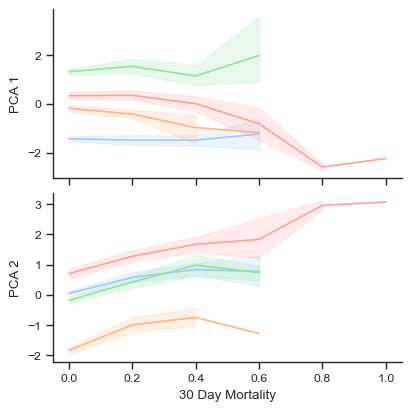

In [33]:
from statannotations.Annotator import Annotator

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    constrained_layout=True,
    sharex=True,
)

for i, col in enumerate(["PCA 1", "PCA 2"]):

    ax = axs[i]

    sns.lineplot(
        data=training_data,
        y=col,
        x="30 Day Mortality",
        hue="Consensus Labels4",
        palette=palette,
        ax=ax,
        legend=False,
    )



    # ax.set_ylabel("")
    # ax.set_yticklabels([])
    # ax.set_yticks([])
fig.set_size_inches(
    (4, 4)
)

fig.savefig(
    "pca_trend.pdf", dpi=300, bbox_inches="tight"
)

In [34]:
from scipy.spatial import distance

centroid_distances = []

for idx, row in training_data.iterrows():

    centroid = centroids.loc[row['Consensus Labels4'], :]

    centroid = centroid[clinical_columns].to_numpy()

    target = row[clinical_columns].to_numpy()

    dist = distance.euclidean(centroid, target)

    centroid_distances.append(dist)

training_data['centroid_distance'] = centroid_distances

In [35]:
training_data['30 Day Mortality'].value_counts()

30 Day Mortality
0.0    906
0.2    307
0.4    120
0.6     24
0.8      2
1.0      1
Name: count, dtype: int64

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_23175/4179640436.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Consensus Labels4', ylabel='30 Day Mortality'>

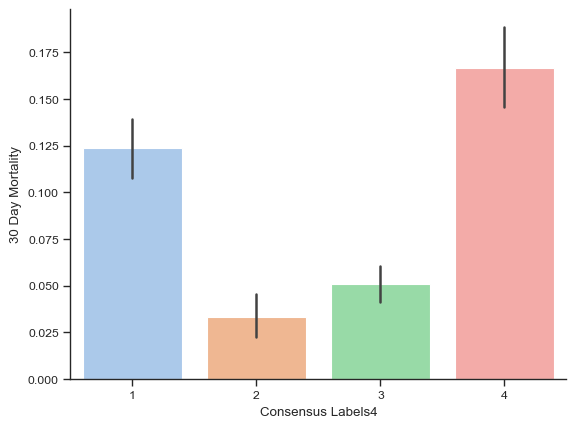

In [36]:
sns.barplot(
    data=training_data,
    x="Consensus Labels4",
    y="30 Day Mortality",
    #hue="30 Day Mortality",
    palette=palette,
)

In [37]:
test = sns.color_palette("gray", n_colors=1)

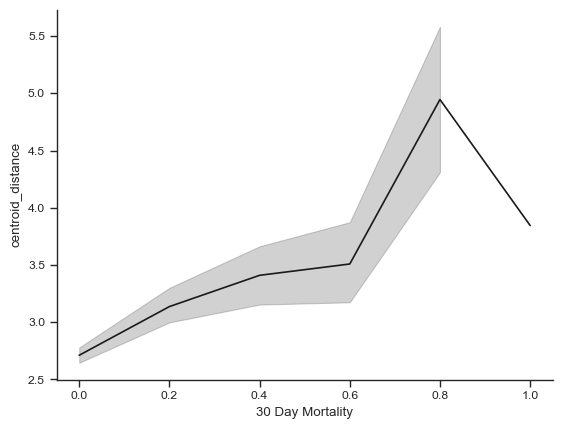

In [41]:
fig, ax = plt.subplots()
sns.lineplot(
    data=training_data,
    x="30 Day Mortality",
    y="centroid_distance",
    #hue="Consensus Labels4",
    #palette="viridis",
    c="k",
    ax=ax
)

sns.despine()

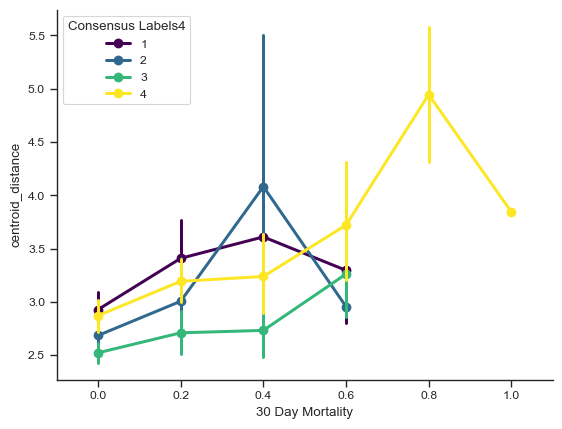

In [42]:
fig, ax = plt.subplots()
sns.pointplot(
    data=training_data,
    x="30 Day Mortality",
    y="centroid_distance",
    hue="Consensus Labels4",
    palette="viridis",
    ax=ax
)

sns.despine()
fig.savefig(
    "centroid_distances_pointplot.pdf", dpi=300, bbox_inches="tight"
)